---

# 📌 多线程核心原理解析与应用指南

### 1. 核心概念：线程 vs 进程
* **进程（Process）：** 资源分配的独立单元。隔离性强，但创建和切换成本高（需分配独立内存和资源）。
* **线程（Thread）：** 任务运行以及调度的基本单元。共享所在进程的资源，创建和切换极其轻量（仅分配栈和寄存器）。
* **本质优势：** 多线程通过**共享资源**避免了系统的重复分配，让任务协作更加轻量化。

### 2. 核心目的：并发与并行的区别
* **并发（Concurrency）：** 逻辑上的“同时执行”。单核 CPU 通过时间片轮转调度交替执行多个线程，适用于处理 I/O 阻塞。

    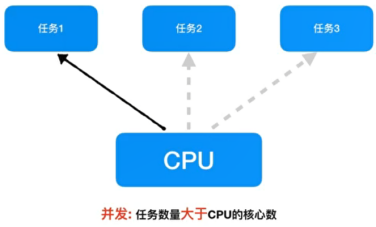

* **并行（Parallelism）：** 物理上的“同时执行”。多核 CPU 将线程分配到不同物理核心上同时运转，适用于加速纯计算任务。

    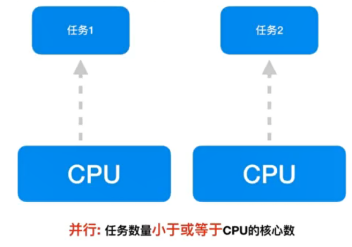

### 3. 多线程如何提升效率？（三大支柱）
* **重叠计算（填补 CPU 空闲）：** 当一个线程因 I/O（读写/网络）阻塞时，操作系统迅速切换到另一个线程执行计算。本质是“时间复用”，不让 CPU 闲置。
* **多核并行（榨干硬件算力）：** 将大任务拆解为子任务，分配给多个 CPU 核心同时运算，成倍缩短计算时间。
* **解耦响应（提升用户体验）：** 将耗时的后台逻辑与 UI 渲染分离，避免单个任务卡死整个主程序。

### 4. 场景适用性对比（何时快，何时慢？）

| 运行环境 | 任务类型 | 单线程 vs 多线程表现 | 核心原因分析 |
| :--- | :--- | :--- | :--- |
| **单核 CPU** | 纯 CPU 计算密集型 | **单线程更快** | 没有物理并行，多线程反而增加了频繁的上下文切换开销。 |
| **单核 CPU** | I/O 密集型 / 混合型 | **多线程更快** | 利用等待 I/O 的时间执行其他线程任务，提高了 CPU 整体利用率。 |
| **多核 CPU** | 纯 CPU 计算密集型 | **多线程显著更快** | 多个物理核心真正同时处理拆分后的子任务，成倍提速。 |

* 多线程不依赖多核，对于多线程任务而言，如果使用单核的话是并发操作，使用多核的话是并行操作。

* **单核多线程加速I/O密集型任务原理：** 对于单核而言，同一时刻只能有一个线程运行在CPU上，当读取线程发动I/O读取指令的时候，相应的硬件开始进行I/O操作，此时
    线程处于阻塞状态，进行线程的切换，使CPU处理计算任务，从而避免了CPU的空等，因此能够起到加速的作用。

* I/O密集型任务：程序的运行时间主要消耗在等待 **输入/输出（Input/Output）** 操作上，而不是 CPU 的计算上。
* CPU计算密集型任务：程序的运行时间主要 **消耗在 CPU 的算术逻辑运算** 上。程序一开始运行，就把 CPU 的计算资源“吃干抹净”。

### 5. 必须警惕的代价（避坑指南）
* **上下文切换开销：** 操作系统保存和恢复寄存器、栈指针等状态需要耗费微秒级时间。盲目开启过多线程会导致 CPU 都在忙于“切换”而非“计算”。
* **资源同步与锁竞争：** 多个线程修改共享数据时必须加锁（如互斥锁）。设计不当会导致阻塞排队，甚至引发程序死锁。

### 6. 核心总结公式
衡量多线程程序最终耗时的理论基准：
> **总耗时 ≈ (总任务时间 / 物理核心数) + 线程切换开销 + 同步排队延迟**

**💡 终极建议：**
I/O 密集型任务（如网络爬虫、文件读写）无脑上多线程（或异步处理）；纯计算型任务（如视频渲染、矩阵运算）的线程数最好与 CPU 的物理核心数保持一致。

---

# 📌 深入理解：多进程的核心架构

## 一、 多进程的核心概念与优势
多进程（Multi-processing）是指操作系统同时运行多个独立的程序实例。

* **核心原理：** 通过“同时利用多个 CPU 核心”和“减少任务间的互相阻塞”来提速。
* **资源分配（独立性）：** 每个进程在启动时，操作系统会为其分配**完全独立的内存空间**（包括代码段、数据段、堆栈等）和系统资源（如文件句柄）。
* **核心优势（高稳定性）：** 强隔离性。一个进程崩溃（比如发生内存越界、段错误），完全不会影响其他进程的运行。
* **🌰 极简案例（计算 100 个数字的平方，4 核 CPU）：**
  * **单进程：** 1 个进程算 100 次 → 耗时 100 秒。
  * **多进程：** 4 个进程各算 25 次（4 核真正并行）→ 耗时约 25 秒。

## 二、 核心答疑：一个进程等同于只占用一个核心吗？
**结论：不一定。“一个进程 = 占用一个核心”是一个常见的直觉误区。** 真实的底层调度非常灵活，主要取决于以下三种情况：

1. **进程内包含多线程：** 进程本质上只是分配资源的“容器”（独立办公室），真正干活的是里面的“线程”（员工）。如果一个进程里开启了 4 个线程，那么在四核 CPU 上，**这单一进程就能同时占满 4 个核心**。
2. **进程数量 > CPU核心数量（时间片轮转）：** 假设只有 4 核 CPU，但开启了 10 个单线程进程。操作系统会通过极快的时间片轮转（上下文切换），让这 10 个进程交替在这 4 个核心上运行。此时核心处于“共享且忙碌”的状态。
3. **操作系统的“动态漂移” vs “绑核”：** 操作系统是一个动态调度员，一个进程前一秒可能在核心 1 运行，下一秒为了平衡发热或负载，会被调度到核心 2。除非程序员在代码中强制设置 **“CPU 亲和性（CPU Affinity）”**（硬性规定进程绑定在某特定核心），否则都是动态分配的。

## 三、 知识扩充：多进程的通信与代价
既然多进程的内存是完全隔离的（互相看不见对方的变量），那它们如何协同工作？这就引出了多进程编程中最大的难点与代价。

### 1. 进程间通信（IPC, Inter-Process Communication）
为了让不同进程交换数据，必须借助操作系统提供的特殊通道，这比多线程直接读写共享内存要慢得多。常见方式包括：
* **管道（Pipe）/ 消息队列（Message Queue）：** 像流水线一样把数据打包发送给另一个进程。
* **共享内存（Shared Memory）：** 在物理内存中开辟一块特殊区域，多个进程都能映射并访问（速度最快，但仍需加锁防止冲突）。
* **套接字（Socket）：** 甚至可以跨越不同的物理计算机进行通信（如分布式的多进程计算）。

### 2. 进程的“昂贵”代价
* **创建开销极大：** 操作系统需要为其分配全新的页表、内存空间等，耗时远超创建线程。
* **切换极慢：** 进程间的上下文切换（Context Switch）需要刷新 CPU 的缓存（TLB 等），会导致显著的性能损耗。

## 四、 多线程 vs 多进程

| 对比维度 | 🧵 多线程 (Multi-threading) | 🚀 多进程 (Multi-processing) |
| :--- | :--- | :--- |
| **通俗比喻** | **多人共用一间办公室协作** | **多个独立办公室同时开工** |
| **内存/资源** | 共享同一块内存（通信极快） | 内存完全独立隔离（需通过 IPC 通信） |
| **适用场景** | I/O 密集型（网络请求、文件读写）、UI渲染 | **纯 CPU 计算密集型（如模型推理、视频渲染）、需极高稳定性的服务** |
| **核心代价** | 极易发生数据竞争、死锁，调试困难 | 占用系统内存大，创建与切换开销极高 |
| **终极目标** | 填补 CPU 的 I/O 等待空白 | 榨干多核 CPU 的绝对物理算力 |

### 💡 语言特性补充：Python 的 GIL 锁
在 Python 开发（如深度学习、数据处理）中，多进程有着特殊的地位：
* Python 解释器自带一个 **GIL（全局解释器锁）**。这导致在同一时刻，一个 Python 进程内**只能有一个线程执行 Python 字节码**。因此不能实现并行操作，只能进行并发操作。
* **结论：** 在 Python 中，如果你的任务是纯计算型（CPU密集型），用多线程是**无法**实现多核加速的！必须使用 **多进程（`multiprocessing`）** 来绕过 GIL 锁，才能真正发挥多核 CPU 的威力。

## 五、 单进程下的多线程（多核利用机制）
**核心结论：单进程的多线程程序，天然可以使用多核！** 只要操作系统支持，线程会被自动分配到不同的 CPU 核心上并行执行（C++、Java、Go 等语言均适用，Python 受限如上所述）。

* **单核 vs 多核的表现差异：**
  * **单核 CPU：** 线程轮流交替运行（并发），提高程序的响应性（如：后台下载时前端不卡），但绝对计算速度**不变快**。
  * **多核 CPU：** 线程被分配到不同核心上同时运行（真正并行），计算能力**显著提升**。
* **核心规则与避坑：**
  * **OS 自动调度：** 程序员只管创建线程，分配哪个核心由操作系统全权负责。
  * **数量阈值：** 理想情况是 **运行的线程数 ≈ CPU核心数**。盲目开几百个计算线程，反而会因为疯狂的“切换开销”导致效率暴跌。
  * **锁的代价：** 多个核心同时修改共享数据时必须加互斥锁。如果抢锁太频繁，多核会退化成“排队干活”，实际并行度大幅下降。